In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Zen Hei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
print('导入完成 ')

In [4]:
# 下载苹果公司 (TSLA) 近两年日线数据
ticker = 'TSLA'
data = yf.download(ticker, start='2022-01-01', end='2024-01-01', progress=False)
price = data['Close'].squeeze()  # 收盘价 squeeze 作用是降维，把只有一列的二维 DataFrame 压成一维 Series
print(f'原始数据后20行：\n{data.tail(20)}')
data[['Open', 'High', 'Low', 'Close', 'Volume']].tail()
print(f'原始数据形状: {data.shape}')
print(f'按照收盘价清洗后的数据,后20行:\n{price.tail(20)}')
print(f'时间范围: {price.index[0].date()} → {price.index[-1].date()}')


原始数据后20行：Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2023-12-01  238.830002  240.190002  231.899994  233.139999  121331700
2023-12-04  235.580002  239.369995  233.289993  235.750000  104099800
2023-12-05  238.720001  246.660004  233.699997  233.869995  137971100
2023-12-06  239.369995  246.570007  239.169998  242.919998  126436200
2023-12-07  242.639999  244.080002  236.979996  241.550003  107142300
2023-12-08  243.839996  245.270004  239.270004  240.270004  103126800
2023-12-11  239.740005  243.440002  237.449997  242.740005   97913900
2023-12-12  237.009995  238.990005  233.869995  238.550003   95328300
2023-12-13  239.289993  240.300003  228.199997  234.190002  146286300
2023-12-14  251.050003  253.880005  240.789993  241.220001  160829200
2023-12-15  253.500000  254.130005  248.300003  251.210007  135932800
2023-12-18 

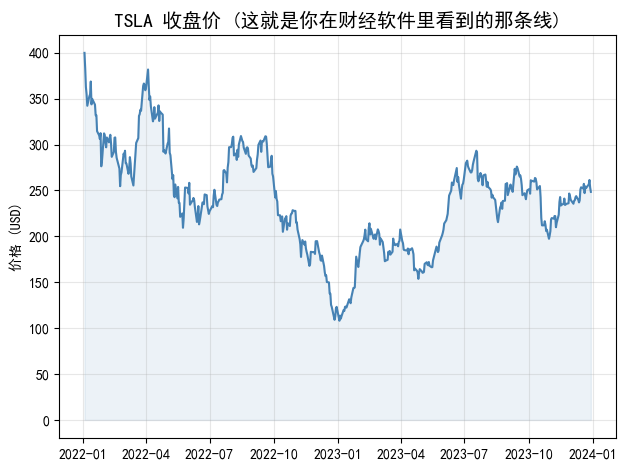

In [5]:
# 绘制收盘价走势

fig, ax = plt.subplots()
ax.plot(price.index, price.values, color='steelblue', linewidth=1.5)
ax.fill_between(price.index, price.values, alpha=0.1, color='steelblue')
ax.set_title(f'{ticker} 收盘价 (这就是你在财经软件里看到的那条线)', fontsize=14)
ax.set_ylabel('价格 (USD)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# 计算简单日收益率（pct_change 就是 (今天-昨天)/昨天）
simple_ret = price.pct_change().dropna()
print(f'简单收益率最后20行：\n{simple_ret.tail(20)}')
print('简单收益率统计：')
print(simple_ret.describe().round(4))
print(f'\n最大单日收益: {simple_ret.max():.2%}  （赚最多的那天）')
print(f'最大单日亏损: {simple_ret.min():.2%}  （亏最多的那天）')

收益率最后20行：
Date
2023-12-01   -0.005207
2023-12-04   -0.013608
2023-12-05    0.013329
2023-12-06    0.002723
2023-12-07    0.013661
2023-12-08    0.004946
2023-12-11   -0.016814
2023-12-12   -0.011387
2023-12-13    0.009620
2023-12-14    0.049145
2023-12-15    0.009759
2023-12-18   -0.005602
2023-12-19    0.020390
2023-12-20   -0.039188
2023-12-21    0.029781
2023-12-22   -0.007701
2023-12-26    0.016116
2023-12-27    0.018822
2023-12-28   -0.031594
2023-12-29   -0.018564
Name: TSLA, dtype: float64
简单收益率统计：
count    500.0000
mean      -0.0002
std        0.0379
min       -0.1224
25%       -0.0210
50%        0.0010
75%        0.0206
max        0.1100
Name: TSLA, dtype: float64

最大单日收益: 11.00%  （赚最多的那天）
最大单日亏损: -12.24%  （亏最多的那天）


对数收益率最后20行：
Date
2023-12-01   -0.005220
2023-12-04   -0.013701
2023-12-05    0.013241
2023-12-06    0.002719
2023-12-07    0.013568
2023-12-08    0.004933
2023-12-11   -0.016957
2023-12-12   -0.011453
2023-12-13    0.009574
2023-12-14    0.047976
2023-12-15    0.009712
2023-12-18   -0.005617
2023-12-19    0.020185
2023-12-20   -0.039977
2023-12-21    0.029346
2023-12-22   -0.007731
2023-12-26    0.015988
2023-12-27    0.018647
2023-12-28   -0.032104
2023-12-29   -0.018738
Name: TSLA, dtype: float64


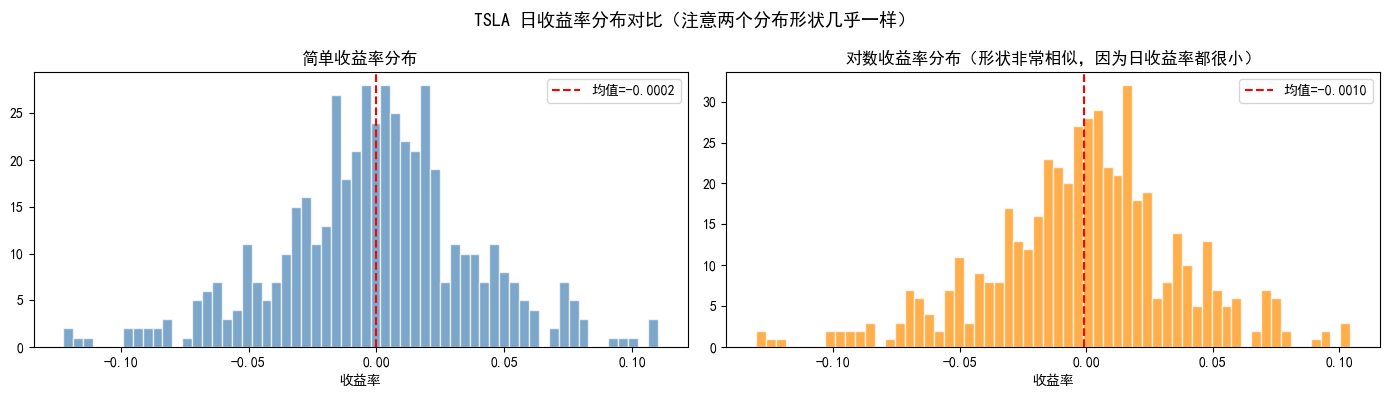

In [9]:
# 计算对数收益率
log_ret = np.log(price / price.shift(1)).dropna()
print(f'对数收益率最后20行：\n{log_ret.tail(20)}')
# 对比两种收益率的分布形状
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
#所有 500 个收益率数值，从最小到最大，切成 60 个等宽的小区间
axes[0].hist(simple_ret, bins=60, color='steelblue', alpha=0.7, edgecolor='white')# 直方图，60个柱体，0.7的透明度
axes[0].set_title('简单收益率分布')
axes[0].set_xlabel('收益率')
axes[0].axvline(simple_ret.mean(), color='red', linestyle='--', label=f'均值={simple_ret.mean():.4f}')# 红色虚线
axes[0].legend() #显示图例 ，就是label的内容

axes[1].hist(log_ret, bins=60, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].set_title('对数收益率分布（形状非常相似，因为日收益率都很小）')
axes[1].set_xlabel('收益率')
axes[1].axvline(log_ret.mean(), color='red', linestyle='--', label=f'均值={log_ret.mean():.4f}')
axes[1].legend() 

plt.suptitle(f'{ticker} 日收益率分布对比（注意两个分布形状几乎一样）', fontsize=13)
plt.tight_layout() # 自动排版命令。它的作用是：自动调整子图之间的间距和边距，让所有标签、标题不会互相重叠或挤出画布。
plt.show()

## 4. 累积收益率

### 「买了这只股票，现在挣了多少」怎么算？

这就是累积收益率要回答的问题。  
把每天的收益率「复利」地乘起来，就得到了从第一天到现在的总收益：

$$\text{累积收益率}_t = (1+r_1) \times (1+r_2) \times \cdots \times (1+r_t) - 1$$

变成代码就是：`(1 + daily_returns).cumprod() - 1`

收益率最后20行：
Date
2023-12-01    0.597184
2023-12-04    0.589058
2023-12-05    0.596909
2023-12-06    0.598535
2023-12-07    0.606711
2023-12-08    0.609712
2023-12-11    0.599460
2023-12-12    0.592634
2023-12-13    0.598335
2023-12-14    0.627740
2023-12-15    0.633866
2023-12-18    0.630316
2023-12-19    0.643168
2023-12-20    0.617963
2023-12-21    0.636367
2023-12-22    0.631466
2023-12-26    0.641643
2023-12-27    0.653720
2023-12-28    0.633066
2023-12-29    0.621314
Name: TSLA, dtype: float64


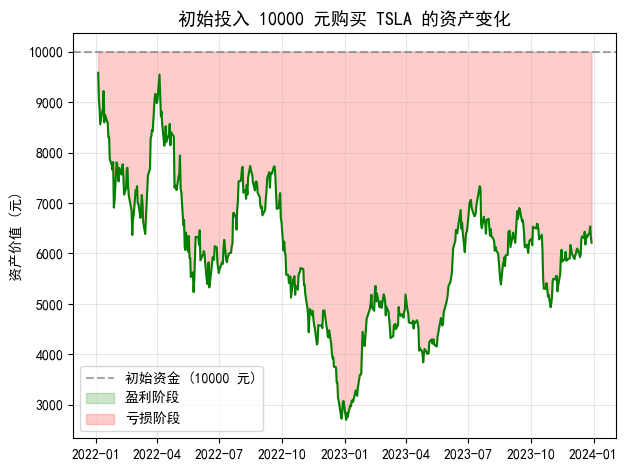

总收益率: -37.87%
最终资产: 6213.14 元


In [11]:
# 计算累积收益率（假设初始投入 10000 元）
initial_capital = 10000
cumulative_ret = (1 + simple_ret).cumprod() #本金，每天随着市场涨跌，最终变成了多少钱。# .cumprod()累乘，把前一天的净值 × 当天的净值
#没有- 1 ，是因为要画资产变化趋势图，不减1，画图更完整，减1的话，如果用来画图就变成了收益率曲线了
print(f'收益率最后20行：\n{cumulative_ret.tail(20)}')
portfolio_value = cumulative_ret * initial_capital

fig, ax = plt.subplots()
ax.plot(portfolio_value.index, portfolio_value.values, color='green', linewidth=1.5)
ax.axhline(initial_capital, color='gray', linestyle='--', alpha=0.7, label='初始资金 (10000 元)')
ax.fill_between(portfolio_value.index, initial_capital, portfolio_value.values,
                where=(portfolio_value.values >= initial_capital),
                alpha=0.2, color='green', label='盈利阶段')
ax.fill_between(portfolio_value.index, initial_capital, portfolio_value.values,
                where=(portfolio_value.values < initial_capital),
                alpha=0.2, color='red', label='亏损阶段')
ax.set_title(f'初始投入 {initial_capital} 元购买 {ticker} 的资产变化', fontsize=13)
ax.set_ylabel('资产价值 (元)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

total_return = cumulative_ret.iloc[-1] - 1
print(f'总收益率: {total_return:.2%}')
print(f'最终资产: {portfolio_value.iloc[-1]:.2f} 元')

## 5. 年化收益率

### 为什么要「年化」？

假设策略 A 持有了 3 个月，赚了 5%；策略 B 持有了 3 年，赚了 30%。哪个更好？

直接比较 5% vs 30% 不公平，因为持有时间不同。**年化收益率就是把所有策略换算成「每年赚多少」，方便横向比较。**

$$\text{年化收益率} = (1 + \text{总收益率})^{\frac{252}{T}} - 1$$

- $T$：实际持有的交易日数
- $252$：美股一年约 252 个交易日（去掉周末和节假日）
- $\frac{252}{T}$：这是「持有了几年」的倒数——1年变成年化就乘以 1，半年就乘以 2

In [12]:
T = len(simple_ret)  # 交易日数
total_ret = cumulative_ret.iloc[-1] - 1
annual_ret = (1 + total_ret) ** (252 / T) - 1

print(f'持有交易日数: {T} 天（约 {T/252:.1f} 年）')
print(f'总收益率:     {total_ret:.2%}')
print(f'年化收益率:   {annual_ret:.2%}  ← 每年平均赚这么多')

持有交易日数: 500 天（约 2.0 年）
总收益率:     -37.87%
年化收益率:   -21.33%  ← 每年平均赚这么多
